# Part 04: Ice Phenology Correlation Analysis

**Goal:** Analyze relationships between ice phenology metrics and lake characteristics

**Key Questions:**
1. How does latitude affect ice-on and ice-off timing?
2. Does lake size (area) influence ice-free duration?
3. Do lake shape metrics (circularity, SDI, convexity) correlate with phenology?
4. What is the inter-annual variability (2019-2023)?
5. Are there spatial patterns or regional clusters?

**Input Data:**
- `alaska_lakes_ice_phenology_2019-2023.csv` - Phenology summary with morphometry

**Outputs:**
- Correlation matrices and scatter plots
- Maps showing spatial patterns
- Inter-annual comparison plots
- Statistical summaries by latitude bands

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Specific warning suppressions instead of blanket ignore
warnings.filterwarnings('ignore', category=FutureWarning, module='google.api_core')
warnings.filterwarnings('ignore', category=FutureWarning, module='pyproj')
warnings.filterwarnings('ignore', message='.*Shapely GEOS.*')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Output paths
FIGURES_DIR = './figures'
RESULTS_GCS = 'gs://wustl-eeps-geospatial/thermokarst_lakes/results'

print("Libraries loaded successfully")

Libraries loaded successfully


## Part 1: Load Phenology Data

In [30]:
# Load phenology results from GCS (exported from notebook 03)
print("Loading phenology data from GCS...")

BUCKET_NAME = 'wustl-eeps-geospatial'
RESULTS_PATH = 'thermokarst_lakes/results'

# Load phenology data
phenology_url = f'gs://{BUCKET_NAME}/{RESULTS_PATH}/alaska_lakes_ice_phenology_2019-2023.csv'
df = pd.read_csv(phenology_url)

print(f"Loaded {len(df):,} lake-year records")
print(f"Unique lakes: {df['lake_id'].nunique():,}")
print(f"Years: {sorted(df['year'].unique())}")
print(f"\nColumns: {list(df.columns)}")

# Show sample
print("\nSample data:")
display(df.head(3))

Loading phenology data from GCS...
Loaded 155,540 lake-year records
Unique lakes: 31,108
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Columns: ['lake_id', 'year', 'centroid_lon', 'centroid_lat', 'area_km2', 'circularity', 'sdi', 'convexity', 'ice_off_date', 'ice_off_doy', 'ice_off_conf', 'ice_on_date', 'ice_on_doy', 'ice_on_conf', 'ice_free_days']

Sample data:


,lake_id,year,centroid_lon,centroid_lat,area_km2,circularity,sdi,convexity,ice_off_date,ice_off_doy,ice_off_conf,ice_on_date,ice_on_doy,ice_on_conf,ice_free_days
0,6316,2019,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2019-06-20,171.0,medium,2019-10-30,303.0,medium,132.0
1,6316,2020,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2020-06-14,166.0,medium,2020-10-12,286.0,medium,120.0
2,6316,2021,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2021-06-21,172.0,medium,2021-09-25,268.0,medium,96.0


In [31]:
# Basic data overview
print("Data Overview:")
print("="*60)
display(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

# Show key phenology stats
print("\n" + "="*60)
print("Key Phenology Variables:")
print("="*60)
for col in ['ice_off_doy', 'ice_on_doy', 'ice_free_days']:
    if col in df.columns:
        n_valid = df[col].notna().sum()
        print(f"{col}: {n_valid} valid values ({100*n_valid/len(df):.1f}%)")

Data Overview:


,lake_id,year,centroid_lon,centroid_lat,area_km2,circularity,sdi,convexity,ice_off_date,ice_off_doy,ice_off_conf,ice_on_date,ice_on_doy,ice_on_conf,ice_free_days
0,6316,2019,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2019-06-20,171.0,medium,2019-10-30,303.0,medium,132.0
1,6316,2020,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2020-06-14,166.0,medium,2020-10-12,286.0,medium,120.0
2,6316,2021,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2021-06-21,172.0,medium,2021-09-25,268.0,medium,96.0
3,6316,2022,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2022-06-28,179.0,medium,2022-10-02,275.0,medium,96.0
4,6316,2023,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2023-07-05,186.0,medium,2023-11-14,318.0,medium,132.0



Data Types:
lake_id            int64
year               int64
centroid_lon     float64
centroid_lat     float64
area_km2         float64
circularity      float64
sdi              float64
convexity        float64
ice_off_date      object
ice_off_doy      float64
ice_off_conf      object
ice_on_date       object
ice_on_doy       float64
ice_on_conf       object
ice_free_days    float64
dtype: object

Missing Values:
lake_id             0
year                0
centroid_lon        0
centroid_lat        0
area_km2            0
circularity         0
sdi                 0
convexity           0
ice_off_date     2975
ice_off_doy      2975
ice_off_conf     2975
ice_on_date      1586
ice_on_doy       1586
ice_on_conf      1586
ice_free_days    4547
dtype: int64

Key Phenology Variables:
ice_off_doy: 152565 valid values (98.1%)
ice_on_doy: 153954 valid values (99.0%)
ice_free_days: 150993 valid values (97.1%)


In [32]:
# Filter to complete records (both ice-off and ice-on detected)
complete = df[
    df['ice_off_doy'].notna() & 
    df['ice_on_doy'].notna()
].copy()

print(f"Complete records (both dates detected): {len(complete):,} / {len(df):,} ({100*len(complete)/len(df):.1f}%)")
print(f"Unique lakes with complete records: {complete['lake_id'].nunique():,}")

# Show phenology summary stats
if len(complete) > 0:
    print(f"\nPhenology Summary (complete records):")
    print(f"  Ice-off DOY: mean={complete['ice_off_doy'].mean():.1f}, median={complete['ice_off_doy'].median():.1f}")
    print(f"  Ice-on DOY:  mean={complete['ice_on_doy'].mean():.1f}, median={complete['ice_on_doy'].median():.1f}")
    if 'ice_free_days' in complete.columns:
        valid_ifd = complete['ice_free_days'].dropna()
        if len(valid_ifd) > 0:
            print(f"  Ice-free days: mean={valid_ifd.mean():.1f}, median={valid_ifd.median():.1f}")

Complete records (both dates detected): 150,993 / 155,540 (97.1%)
Unique lakes with complete records: 30,851

Phenology Summary (complete records):
  Ice-off DOY: mean=163.2, median=164.0
  Ice-on DOY:  mean=280.5, median=278.0
  Ice-free days: mean=117.2, median=116.0


## Part 2: Latitude Effects on Ice Phenology

In [33]:
# Create latitude bands based on actual data range
lat_min = complete['centroid_lat'].min()
lat_max = complete['centroid_lat'].max()
lat_range = lat_max - lat_min
print(f"Latitude range: {lat_min:.2f}°N to {lat_max:.2f}°N (range: {lat_range:.2f}°)")

# Adjust number of bins based on latitude range
if lat_range < 1:
    # Narrow range - use quartiles instead
    complete['lat_band'] = pd.qcut(
        complete['centroid_lat'], 
        q=4, 
        labels=['Q1 (South)', 'Q2', 'Q3', 'Q4 (North)'],
        duplicates='drop'
    )
    print("\nUsing quartile-based latitude bands (narrow latitude range)")
else:
    # Wide range - use 1-degree bins
    lat_bins = np.arange(np.floor(lat_min), np.ceil(lat_max) + 1, 1)
    lat_labels = [f'{lat_bins[i]:.0f}-{lat_bins[i+1]:.0f}°N' for i in range(len(lat_bins)-1)]
    complete['lat_band'] = pd.cut(
        complete['centroid_lat'], 
        bins=lat_bins,
        labels=lat_labels
    )

print("\nLakes per latitude band:")
print(complete['lat_band'].value_counts().sort_index())

Latitude range: 69.00°N to 71.34°N (range: 2.34°)

Lakes per latitude band:
lat_band
69-70°N     43278
70-71°N    105122
71-72°N      2593
Name: count, dtype: int64


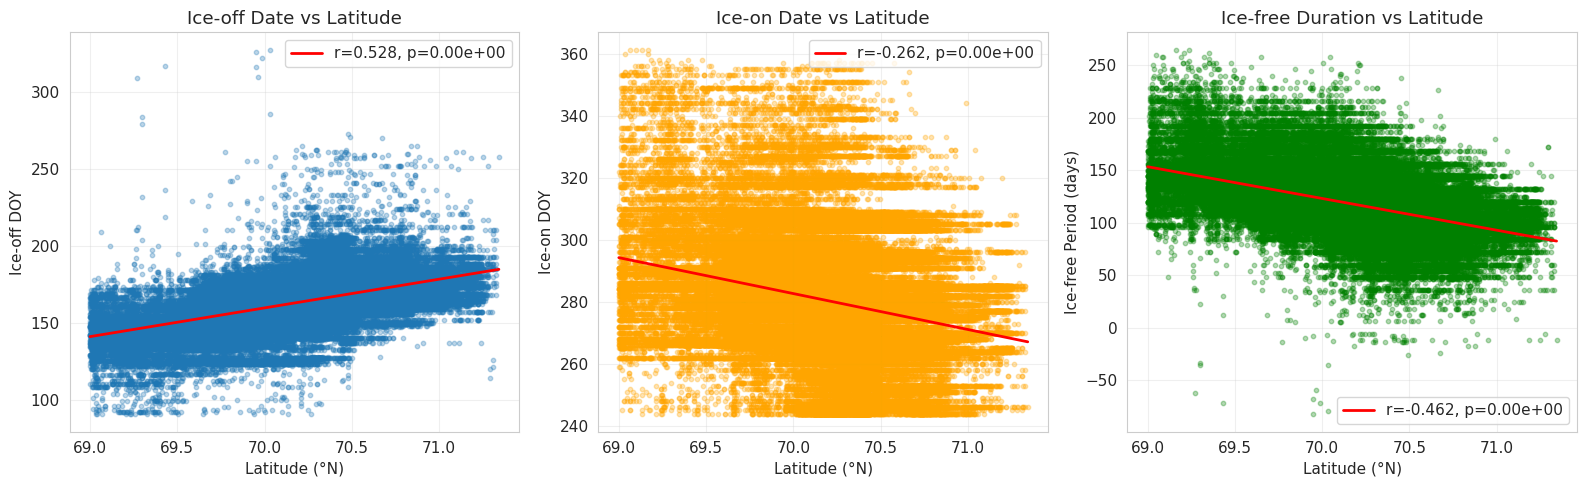

Saved: latitude_phenology_correlations.png


In [34]:
# Latitude vs phenology scatter plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ice-off vs latitude
ax = axes[0]
ax.scatter(complete['centroid_lat'], complete['ice_off_doy'], alpha=0.3, s=10)
# Add regression line
mask = complete['centroid_lat'].notna() & complete['ice_off_doy'].notna()
slope, intercept, r, p, se = stats.linregress(complete.loc[mask, 'centroid_lat'], complete.loc[mask, 'ice_off_doy'])
x_line = np.linspace(complete['centroid_lat'].min(), complete['centroid_lat'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label=f'r={r:.3f}, p={p:.2e}')
ax.set_xlabel('Latitude (°N)')
ax.set_ylabel('Ice-off DOY')
ax.set_title('Ice-off Date vs Latitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Ice-on vs latitude
ax = axes[1]
ax.scatter(complete['centroid_lat'], complete['ice_on_doy'], alpha=0.3, s=10, color='orange')
mask = complete['centroid_lat'].notna() & complete['ice_on_doy'].notna()
slope, intercept, r, p, se = stats.linregress(complete.loc[mask, 'centroid_lat'], complete.loc[mask, 'ice_on_doy'])
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label=f'r={r:.3f}, p={p:.2e}')
ax.set_xlabel('Latitude (°N)')
ax.set_ylabel('Ice-on DOY')
ax.set_title('Ice-on Date vs Latitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Ice-free days vs latitude
ax = axes[2]
ax.scatter(complete['centroid_lat'], complete['ice_free_days'], alpha=0.3, s=10, color='green')
mask = complete['centroid_lat'].notna() & complete['ice_free_days'].notna()
slope, intercept, r, p, se = stats.linregress(complete.loc[mask, 'centroid_lat'], complete.loc[mask, 'ice_free_days'])
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label=f'r={r:.3f}, p={p:.2e}')
ax.set_xlabel('Latitude (°N)')
ax.set_ylabel('Ice-free Period (days)')
ax.set_title('Ice-free Duration vs Latitude')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/latitude_phenology_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: latitude_phenology_correlations.png")

In [35]:
# Summary statistics by latitude band
lat_summary = complete.groupby('lat_band').agg({
    'ice_off_doy': ['mean', 'std', 'count'],
    'ice_on_doy': ['mean', 'std'],
    'ice_free_days': ['mean', 'std']
}).round(1)

print("Phenology by Latitude Band:")
print("="*60)
display(lat_summary)

Phenology by Latitude Band:


ice_off_doy               ice_on_doy       ice_free_days      
                mean   std   count       mean   std          mean   std
lat_band                                                               
69-70°N        153.5  13.5   43278      286.7  18.3         133.2  26.7
70-71°N        166.9  12.5  105122      278.0  17.0         111.1  23.3
71-72°N        176.0  12.3    2593      274.8  12.8          98.8  18.2

## Part 3: Lake Size Effects

In [36]:
# Create size classes
complete['size_class'] = pd.cut(
    complete['area_km2'],
    bins=[0, 0.01, 0.1, 1, 10, 100],
    labels=['<0.01', '0.01-0.1', '0.1-1', '1-10', '>10']
)

print("Lakes per size class:")
print(complete['size_class'].value_counts().sort_index())

Lakes per size class:
size_class
<0.01           0
0.01-0.1    92680
0.1-1       49862
1-10         8223
>10           223
Name: count, dtype: int64


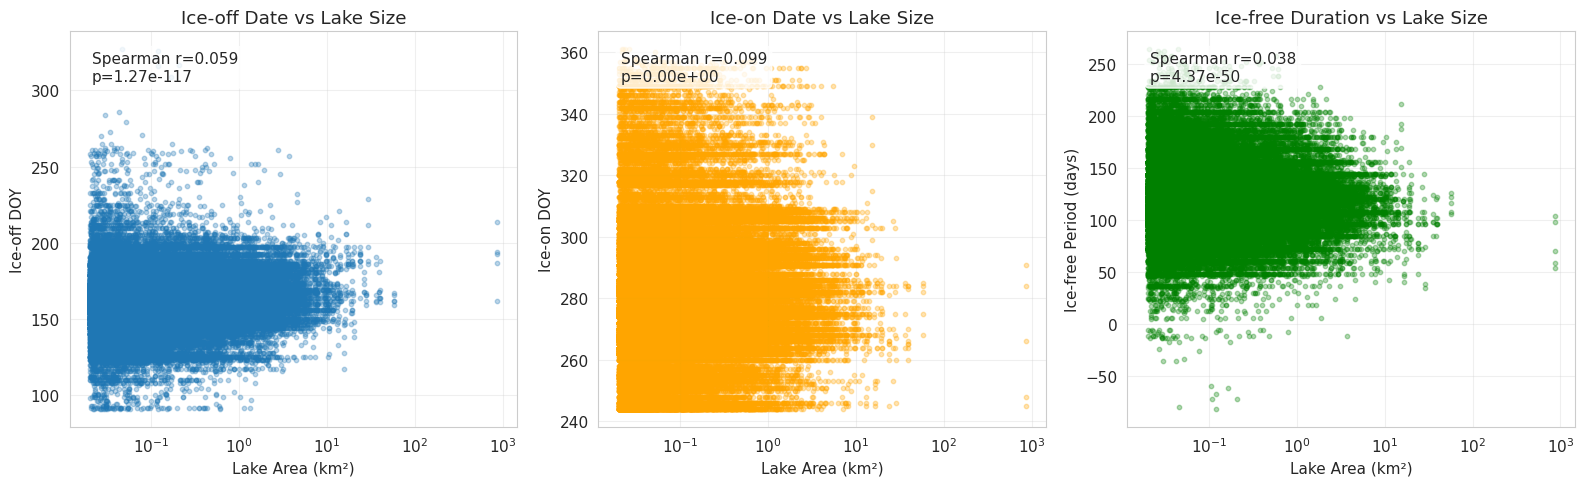

Saved: size_phenology_correlations.png


In [37]:
# Lake size vs phenology
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ice-off vs area (log scale)
ax = axes[0]
ax.scatter(complete['area_km2'], complete['ice_off_doy'], alpha=0.3, s=10)
ax.set_xscale('log')
ax.set_xlabel('Lake Area (km²)')
ax.set_ylabel('Ice-off DOY')
ax.set_title('Ice-off Date vs Lake Size')
# Correlation on log-transformed area
mask = (complete['area_km2'] > 0) & complete['ice_off_doy'].notna()
r, p = stats.spearmanr(complete.loc[mask, 'area_km2'], complete.loc[mask, 'ice_off_doy'])
ax.text(0.05, 0.95, f'Spearman r={r:.3f}\np={p:.2e}', transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.3)

# Ice-on vs area
ax = axes[1]
ax.scatter(complete['area_km2'], complete['ice_on_doy'], alpha=0.3, s=10, color='orange')
ax.set_xscale('log')
ax.set_xlabel('Lake Area (km²)')
ax.set_ylabel('Ice-on DOY')
ax.set_title('Ice-on Date vs Lake Size')
mask = (complete['area_km2'] > 0) & complete['ice_on_doy'].notna()
r, p = stats.spearmanr(complete.loc[mask, 'area_km2'], complete.loc[mask, 'ice_on_doy'])
ax.text(0.05, 0.95, f'Spearman r={r:.3f}\np={p:.2e}', transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.3)

# Ice-free days vs area
ax = axes[2]
ax.scatter(complete['area_km2'], complete['ice_free_days'], alpha=0.3, s=10, color='green')
ax.set_xscale('log')
ax.set_xlabel('Lake Area (km²)')
ax.set_ylabel('Ice-free Period (days)')
ax.set_title('Ice-free Duration vs Lake Size')
mask = (complete['area_km2'] > 0) & complete['ice_free_days'].notna()
r, p = stats.spearmanr(complete.loc[mask, 'area_km2'], complete.loc[mask, 'ice_free_days'])
ax.text(0.05, 0.95, f'Spearman r={r:.3f}\np={p:.2e}', transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/size_phenology_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: size_phenology_correlations.png")

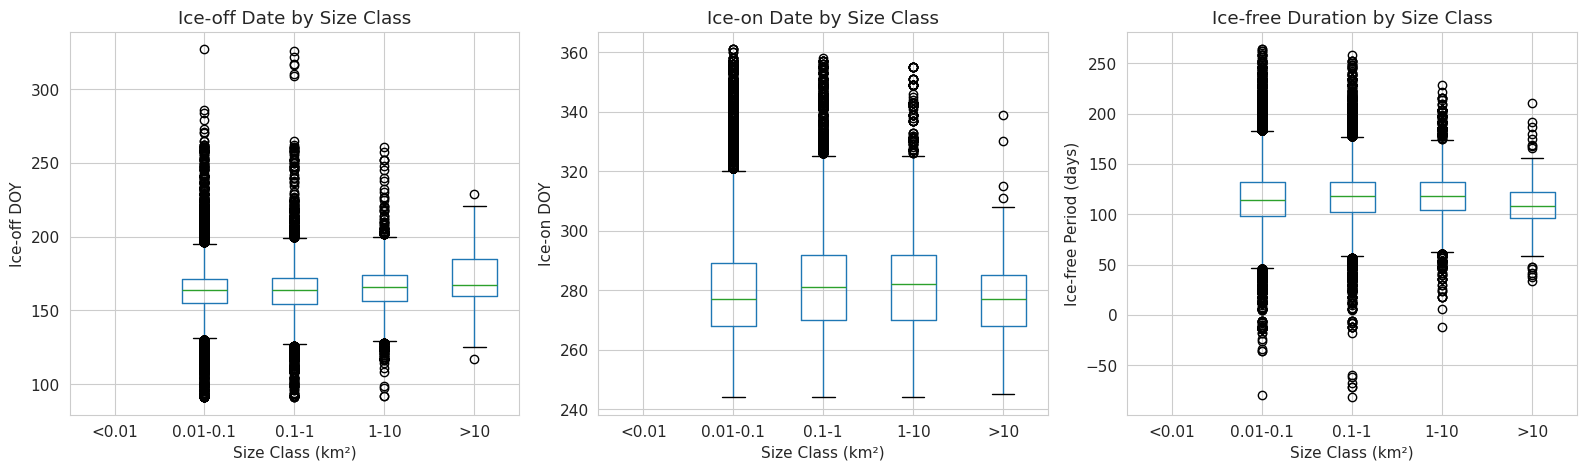

Saved: size_class_boxplots.png


In [38]:
# Box plots by size class
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ice-off by size class
ax = axes[0]
complete.boxplot(column='ice_off_doy', by='size_class', ax=ax)
ax.set_xlabel('Size Class (km²)')
ax.set_ylabel('Ice-off DOY')
ax.set_title('Ice-off Date by Size Class')
plt.suptitle('')

# Ice-on by size class
ax = axes[1]
complete.boxplot(column='ice_on_doy', by='size_class', ax=ax)
ax.set_xlabel('Size Class (km²)')
ax.set_ylabel('Ice-on DOY')
ax.set_title('Ice-on Date by Size Class')
plt.suptitle('')

# Ice-free days by size class
ax = axes[2]
complete.boxplot(column='ice_free_days', by='size_class', ax=ax)
ax.set_xlabel('Size Class (km²)')
ax.set_ylabel('Ice-free Period (days)')
ax.set_title('Ice-free Duration by Size Class')
plt.suptitle('')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/size_class_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: size_class_boxplots.png")

In [39]:
# Summary by size class
size_summary = complete.groupby('size_class').agg({
    'ice_off_doy': ['mean', 'std', 'count'],
    'ice_on_doy': ['mean', 'std'],
    'ice_free_days': ['mean', 'std']
}).round(1)

print("Phenology by Size Class:")
print("="*60)
display(size_summary)

Phenology by Size Class:


ice_off_doy              ice_on_doy       ice_free_days      
                  mean   std  count       mean   std          mean   std
size_class                                                              
<0.01              NaN   NaN      0        NaN   NaN           NaN   NaN
0.01-0.1         162.6  13.9  92680      279.5  18.0         116.8  26.5
0.1-1            163.9  14.6  49862      282.0  17.5         118.1  26.2
1-10             165.4  14.8   8223      282.5  16.5         117.1  24.8
>10              170.4  17.8    223      277.7  15.2         107.3  27.4

## Part 4: Shape Metrics Correlations

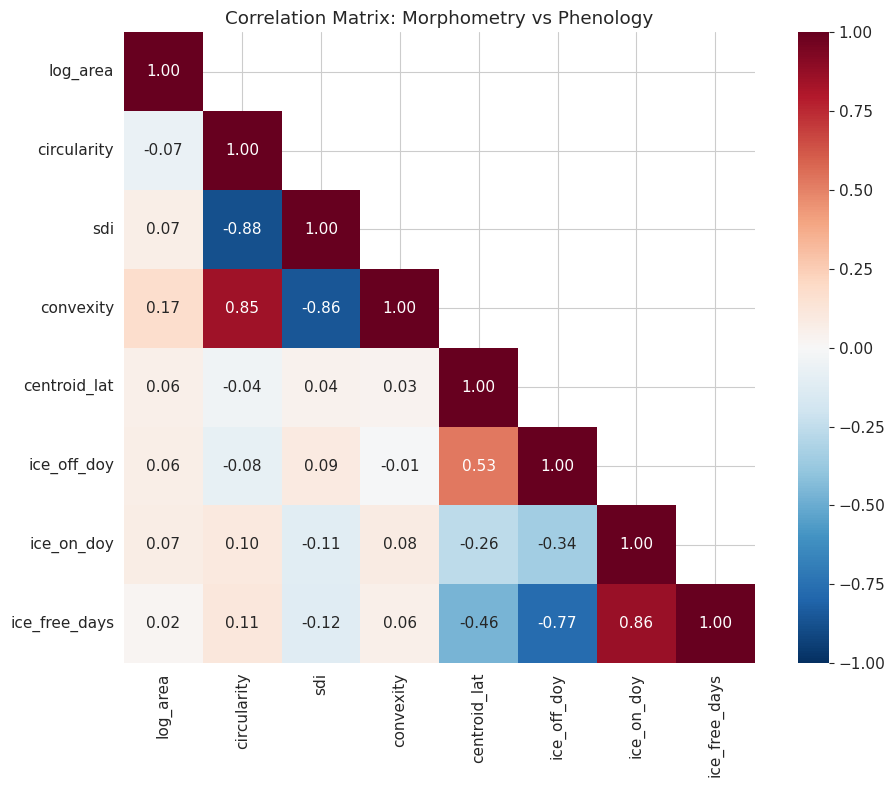

Saved: correlation_matrix.png


In [40]:
# Correlation matrix for all numeric variables
corr_vars = ['area_km2', 'circularity', 'sdi', 'convexity', 'centroid_lat',
             'ice_off_doy', 'ice_on_doy', 'ice_free_days']

# Use log area for better correlation
complete['log_area'] = np.log10(complete['area_km2'])
corr_vars_log = ['log_area', 'circularity', 'sdi', 'convexity', 'centroid_lat',
                 'ice_off_doy', 'ice_on_doy', 'ice_free_days']

corr_matrix = complete[corr_vars_log].corr()

# Plot correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Correlation Matrix: Morphometry vs Phenology')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: correlation_matrix.png")

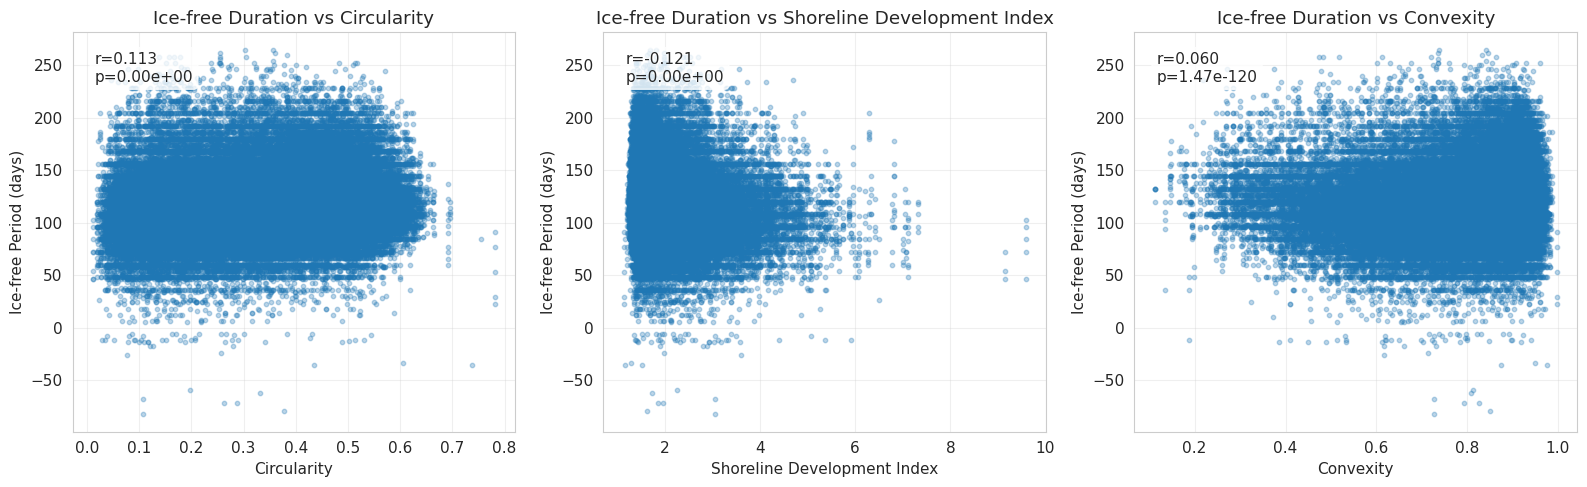

Saved: shape_phenology_correlations.png


In [41]:
# Shape metrics vs ice-free days
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

shape_vars = ['circularity', 'sdi', 'convexity']
shape_labels = ['Circularity', 'Shoreline Development Index', 'Convexity']

for i, (var, label) in enumerate(zip(shape_vars, shape_labels)):
    ax = axes[i]
    ax.scatter(complete[var], complete['ice_free_days'], alpha=0.3, s=10)
    
    # Add correlation
    mask = complete[var].notna() & complete['ice_free_days'].notna()
    r, p = stats.pearsonr(complete.loc[mask, var], complete.loc[mask, 'ice_free_days'])
    ax.text(0.05, 0.95, f'r={r:.3f}\np={p:.2e}', transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel(label)
    ax.set_ylabel('Ice-free Period (days)')
    ax.set_title(f'Ice-free Duration vs {label}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/shape_phenology_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shape_phenology_correlations.png")

## Part 5: Inter-annual Variability

In [42]:
# Phenology statistics by year
years = complete['year'].unique()
print(f"Years in dataset: {sorted(years)}")

if len(years) > 1:
    year_summary = complete.groupby('year').agg({
        'ice_off_doy': ['mean', 'std', 'median', 'count'],
        'ice_on_doy': ['mean', 'std', 'median'],
        'ice_free_days': ['mean', 'std', 'median']
    }).round(1)

    print("\nPhenology Statistics by Year:")
    print("="*60)
    display(year_summary)
else:
    print(f"\nOnly single year ({years[0]}) in dataset - inter-annual analysis not applicable")
    print(f"\nPhenology Statistics for {years[0]}:")
    print(f"  Ice-off DOY: mean={complete['ice_off_doy'].mean():.1f}, std={complete['ice_off_doy'].std():.1f}")
    print(f"  Ice-on DOY:  mean={complete['ice_on_doy'].mean():.1f}, std={complete['ice_on_doy'].std():.1f}")
    if complete['ice_free_days'].notna().sum() > 0:
        print(f"  Ice-free:    mean={complete['ice_free_days'].mean():.1f}, std={complete['ice_free_days'].std():.1f}")

Years in dataset: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Phenology Statistics by Year:


ice_off_doy                     ice_on_doy              ice_free_days  \
            mean   std median  count       mean   std median          mean   
year                                                                         
2019       161.4  17.8  161.0  29594      292.2  18.5  291.0         130.8   
2020       161.6  12.7  160.0  30604      275.9  15.4  274.0         114.3   
2021       160.5  13.5  162.0  30471      269.3  12.4  268.0         108.9   
2022       169.5  11.3  169.0  30338      276.2  13.6  275.0         106.6   
2023       163.1  13.3  164.0  29986      289.2  17.1  286.0         126.2   

                   
       std median  
year               
2019  28.8  132.0  
2020  25.3  114.0  
2021  22.2  108.0  
2022  21.4  108.0  
2023  24.6  123.0

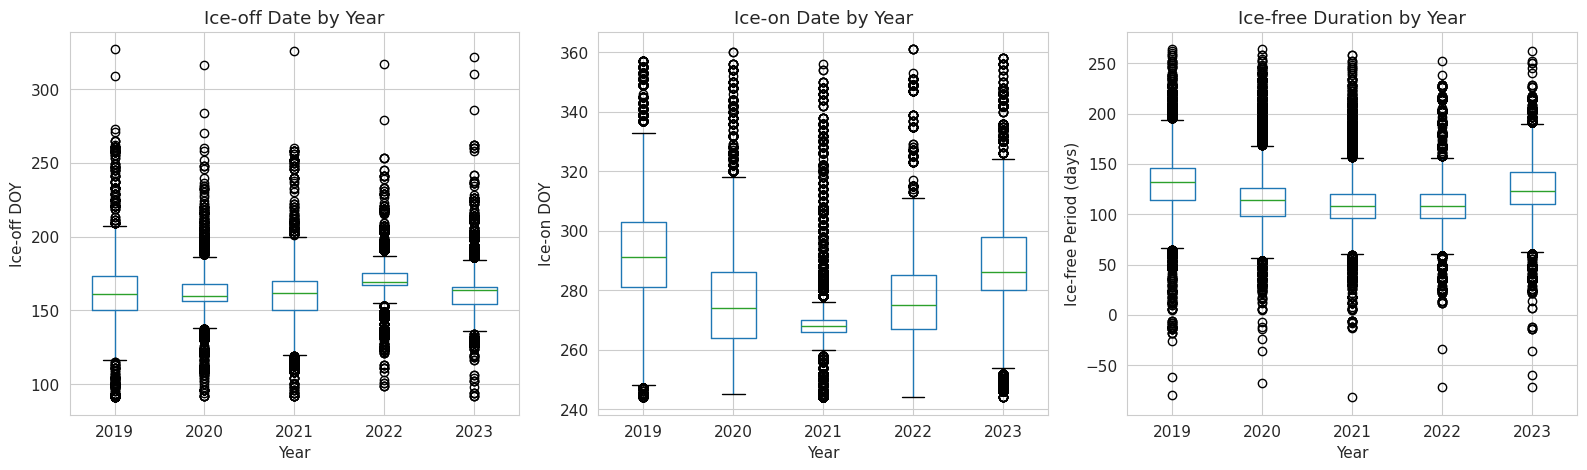

Saved: interannual_variability.png


In [43]:
# Box plots by year (or single year distribution)
years = complete['year'].unique()

if len(years) > 1:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Ice-off by year
    ax = axes[0]
    complete.boxplot(column='ice_off_doy', by='year', ax=ax)
    ax.set_xlabel('Year')
    ax.set_ylabel('Ice-off DOY')
    ax.set_title('Ice-off Date by Year')
    plt.suptitle('')

    # Ice-on by year
    ax = axes[1]
    complete.boxplot(column='ice_on_doy', by='year', ax=ax)
    ax.set_xlabel('Year')
    ax.set_ylabel('Ice-on DOY')
    ax.set_title('Ice-on Date by Year')
    plt.suptitle('')

    # Ice-free days by year
    ax = axes[2]
    complete.boxplot(column='ice_free_days', by='year', ax=ax)
    ax.set_xlabel('Year')
    ax.set_ylabel('Ice-free Period (days)')
    ax.set_title('Ice-free Duration by Year')
    plt.suptitle('')

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/interannual_variability.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: interannual_variability.png")
else:
    # Show distribution for single year
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    ax = axes[0]
    ax.hist(complete['ice_off_doy'].dropna(), bins=20, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Ice-off DOY')
    ax.set_ylabel('Count')
    ax.set_title(f'Ice-off Date Distribution ({years[0]})')
    ax.axvline(complete['ice_off_doy'].median(), color='red', linestyle='--', label=f"Median: {complete['ice_off_doy'].median():.0f}")
    ax.legend()
    
    ax = axes[1]
    ax.hist(complete['ice_on_doy'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='orange')
    ax.set_xlabel('Ice-on DOY')
    ax.set_ylabel('Count')
    ax.set_title(f'Ice-on Date Distribution ({years[0]})')
    ax.axvline(complete['ice_on_doy'].median(), color='red', linestyle='--', label=f"Median: {complete['ice_on_doy'].median():.0f}")
    ax.legend()
    
    ax = axes[2]
    ifd = complete['ice_free_days'].dropna()
    if len(ifd) > 0:
        ax.hist(ifd, bins=20, edgecolor='black', alpha=0.7, color='green')
        ax.axvline(ifd.median(), color='red', linestyle='--', label=f"Median: {ifd.median():.0f}")
        ax.legend()
    ax.set_xlabel('Ice-free Period (days)')
    ax.set_ylabel('Count')
    ax.set_title(f'Ice-free Duration Distribution ({years[0]})')
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/phenology_distributions_single_year.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: phenology_distributions_single_year.png")

In [44]:
# Year-to-year consistency for individual lakes
years = complete['year'].unique()

if len(years) >= 3:
    # Calculate standard deviation of ice-free days for each lake across years
    lake_variability = complete.groupby('lake_id').agg({
        'ice_free_days': ['mean', 'std', 'count'],
        'area_km2': 'first',
        'centroid_lat': 'first'
    })
    lake_variability.columns = ['ice_free_mean', 'ice_free_std', 'n_years', 'area_km2', 'centroid_lat']
    lake_variability = lake_variability[lake_variability['n_years'] >= 3].copy()  # At least 3 years

    print(f"Lakes with ≥3 years of data: {len(lake_variability):,}")
    print(f"\nInter-annual variability (std of ice-free days):")
    print(f"  Mean:   {lake_variability['ice_free_std'].mean():.1f} days")
    print(f"  Median: {lake_variability['ice_free_std'].median():.1f} days")
    print(f"  Max:    {lake_variability['ice_free_std'].max():.1f} days")
else:
    print(f"Only {len(years)} year(s) in dataset - inter-annual variability analysis requires ≥3 years")
    print("\nShowing within-year variability statistics instead:")
    print(f"  Ice-off DOY std:   {complete['ice_off_doy'].std():.1f}")
    print(f"  Ice-on DOY std:    {complete['ice_on_doy'].std():.1f}")
    ifd = complete['ice_free_days'].dropna()
    if len(ifd) > 0:
        print(f"  Ice-free days std: {ifd.std():.1f}")

Lakes with ≥3 years of data: 30,511

Inter-annual variability (std of ice-free days):
  Mean:   16.5 days
  Median: 15.5 days
  Max:    64.3 days


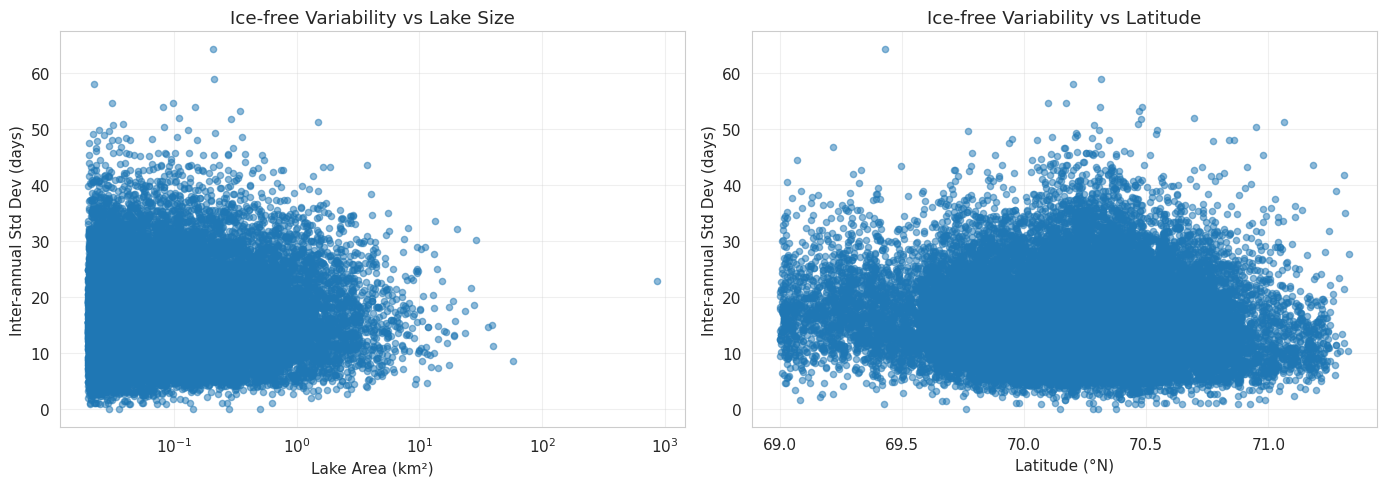

Saved: interannual_variability_factors.png


In [45]:
# Plot variability vs lake characteristics
years = complete['year'].unique()

if len(years) >= 3 and 'lake_variability' in dir() and len(lake_variability) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Variability vs size
    ax = axes[0]
    ax.scatter(lake_variability['area_km2'], lake_variability['ice_free_std'], alpha=0.5, s=20)
    ax.set_xscale('log')
    ax.set_xlabel('Lake Area (km²)')
    ax.set_ylabel('Inter-annual Std Dev (days)')
    ax.set_title('Ice-free Variability vs Lake Size')
    ax.grid(True, alpha=0.3)

    # Variability vs latitude
    ax = axes[1]
    ax.scatter(lake_variability['centroid_lat'], lake_variability['ice_free_std'], alpha=0.5, s=20)
    ax.set_xlabel('Latitude (°N)')
    ax.set_ylabel('Inter-annual Std Dev (days)')
    ax.set_title('Ice-free Variability vs Latitude')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/interannual_variability_factors.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: interannual_variability_factors.png")
else:
    # Show within-year relationships with single year data
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Ice-free days vs size
    ax = axes[0]
    ifd_valid = complete[complete['ice_free_days'].notna()]
    if len(ifd_valid) > 0:
        ax.scatter(ifd_valid['area_km2'], ifd_valid['ice_free_days'], alpha=0.5, s=30)
        ax.set_xscale('log')
        ax.set_xlabel('Lake Area (km²)')
        ax.set_ylabel('Ice-free Days')
        ax.set_title('Ice-free Duration vs Lake Size')
        ax.grid(True, alpha=0.3)
    
    # Ice-free days vs latitude
    ax = axes[1]
    if len(ifd_valid) > 0:
        ax.scatter(ifd_valid['centroid_lat'], ifd_valid['ice_free_days'], alpha=0.5, s=30)
        ax.set_xlabel('Latitude (°N)')
        ax.set_ylabel('Ice-free Days')
        ax.set_title('Ice-free Duration vs Latitude')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/ice_free_vs_characteristics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: ice_free_vs_characteristics.png")

## Part 6: Spatial Patterns

In [46]:
# Aggregate by lake (mean across years)
lake_mean = complete.groupby('lake_id').agg({
    'centroid_lon': 'first',
    'centroid_lat': 'first',
    'area_km2': 'first',
    'ice_off_doy': 'mean',
    'ice_on_doy': 'mean',
    'ice_free_days': 'mean'
}).reset_index()

print(f"Aggregated {len(lake_mean):,} lakes")

Aggregated 30,851 lakes


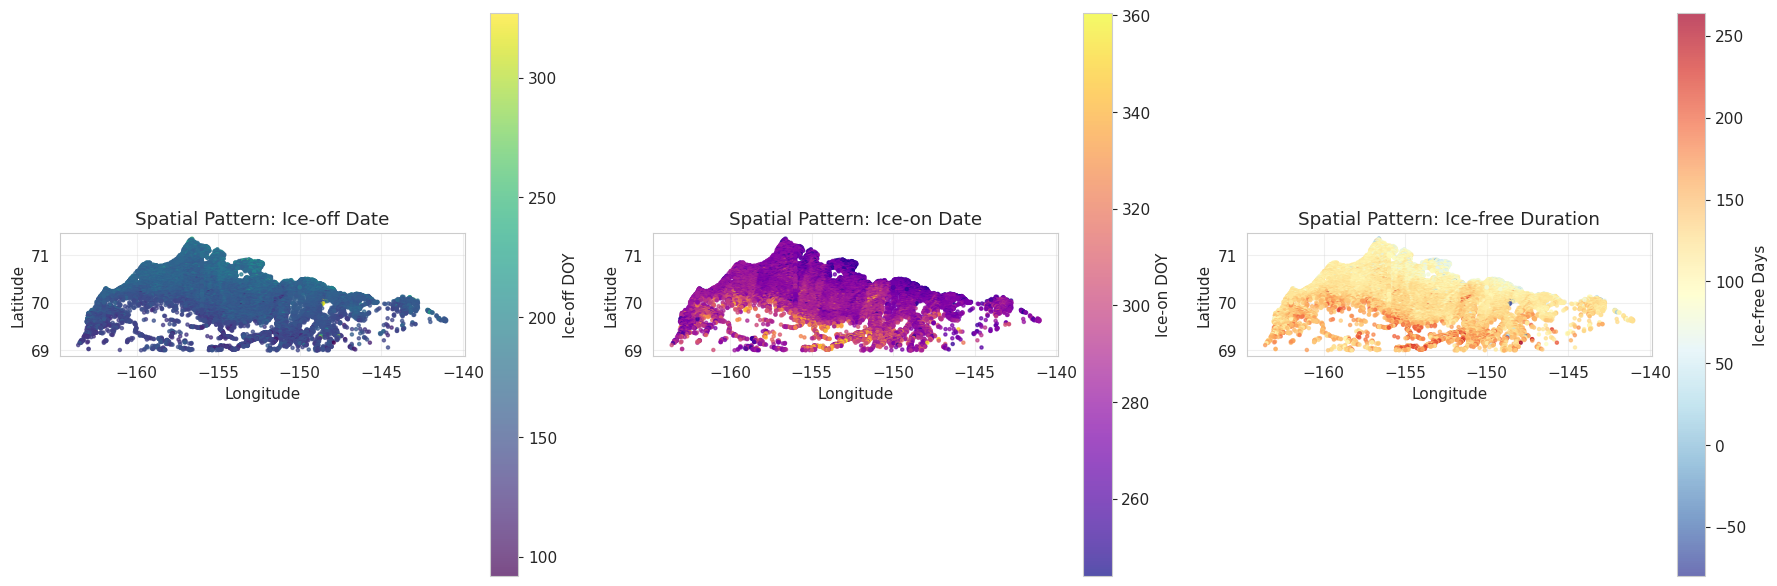

Saved: spatial_phenology_maps.png


In [47]:
# Spatial maps of phenology
# Correct aspect ratio for ~70°N latitude (cos(70°) ≈ 0.34)
aspect_ratio = np.cos(np.radians(70))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Ice-off map
ax = axes[0]
scatter = ax.scatter(lake_mean['centroid_lon'], lake_mean['centroid_lat'],
                     c=lake_mean['ice_off_doy'], cmap='viridis', s=5, alpha=0.7)
plt.colorbar(scatter, ax=ax, label='Ice-off DOY')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial Pattern: Ice-off Date')
ax.set_aspect(1/aspect_ratio)  # Latitude degrees per longitude degree
ax.grid(True, alpha=0.3)

# Ice-on map
ax = axes[1]
scatter = ax.scatter(lake_mean['centroid_lon'], lake_mean['centroid_lat'],
                     c=lake_mean['ice_on_doy'], cmap='plasma', s=5, alpha=0.7)
plt.colorbar(scatter, ax=ax, label='Ice-on DOY')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial Pattern: Ice-on Date')
ax.set_aspect(1/aspect_ratio)
ax.grid(True, alpha=0.3)

# Ice-free map
ax = axes[2]
scatter = ax.scatter(lake_mean['centroid_lon'], lake_mean['centroid_lat'],
                     c=lake_mean['ice_free_days'], cmap='RdYlBu_r', s=5, alpha=0.7)
plt.colorbar(scatter, ax=ax, label='Ice-free Days')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial Pattern: Ice-free Duration')
ax.set_aspect(1/aspect_ratio)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/spatial_phenology_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: spatial_phenology_maps.png")

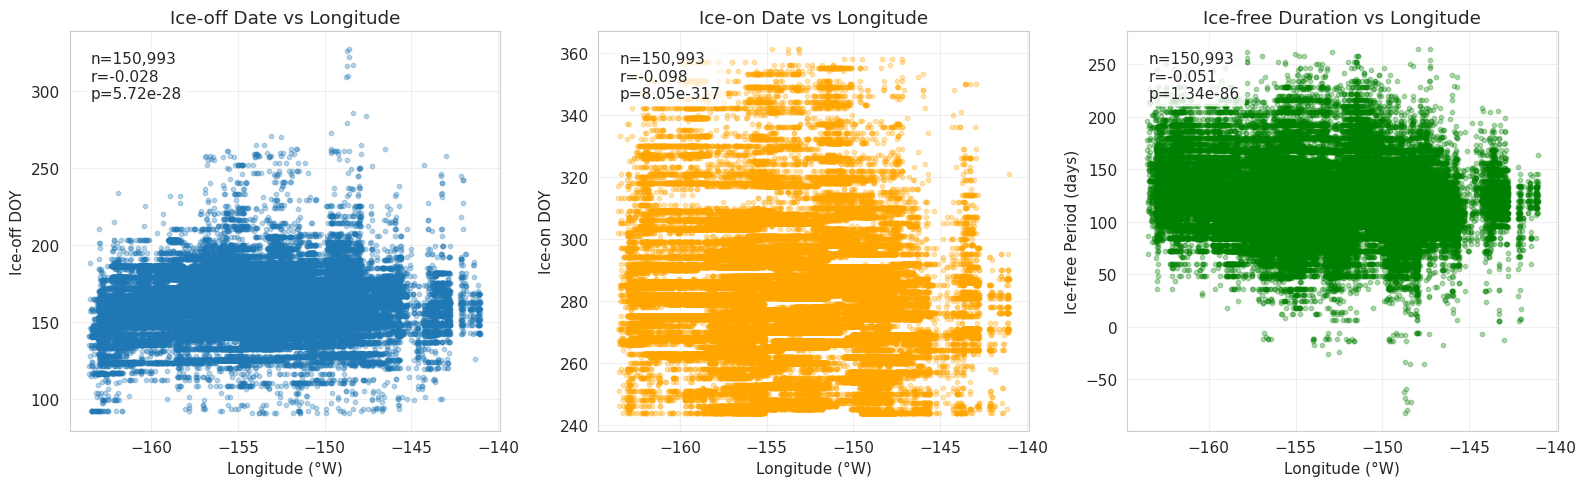

Saved: longitude_phenology_correlations.png


In [48]:
# Longitude effects (coastal vs inland)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ice-off vs longitude
ax = axes[0]
ax.scatter(complete['centroid_lon'], complete['ice_off_doy'], alpha=0.3, s=10)
mask_off = complete['centroid_lon'].notna() & complete['ice_off_doy'].notna()
r, p = stats.pearsonr(complete.loc[mask_off, 'centroid_lon'], complete.loc[mask_off, 'ice_off_doy'])
n = mask_off.sum()
ax.text(0.05, 0.95, f'n={n:,}\nr={r:.3f}\np={p:.2e}', transform=ax.transAxes,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('Longitude (°W)')
ax.set_ylabel('Ice-off DOY')
ax.set_title('Ice-off Date vs Longitude')
ax.grid(True, alpha=0.3)

# Ice-on vs longitude
ax = axes[1]
ax.scatter(complete['centroid_lon'], complete['ice_on_doy'], alpha=0.3, s=10, color='orange')
mask_on = complete['centroid_lon'].notna() & complete['ice_on_doy'].notna()
r, p = stats.pearsonr(complete.loc[mask_on, 'centroid_lon'], complete.loc[mask_on, 'ice_on_doy'])
n = mask_on.sum()
ax.text(0.05, 0.95, f'n={n:,}\nr={r:.3f}\np={p:.2e}', transform=ax.transAxes,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('Longitude (°W)')
ax.set_ylabel('Ice-on DOY')
ax.set_title('Ice-on Date vs Longitude')
ax.grid(True, alpha=0.3)

# Ice-free vs longitude
ax = axes[2]
ax.scatter(complete['centroid_lon'], complete['ice_free_days'], alpha=0.3, s=10, color='green')
mask_free = complete['centroid_lon'].notna() & complete['ice_free_days'].notna()
r, p = stats.pearsonr(complete.loc[mask_free, 'centroid_lon'], complete.loc[mask_free, 'ice_free_days'])
n = mask_free.sum()
ax.text(0.05, 0.95, f'n={n:,}\nr={r:.3f}\np={p:.2e}', transform=ax.transAxes,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('Longitude (°W)')
ax.set_ylabel('Ice-free Period (days)')
ax.set_title('Ice-free Duration vs Longitude')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/longitude_phenology_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: longitude_phenology_correlations.png")

## Part 7: Temperature-Controlled Regression Analysis

Assess how much of ice phenology variance is explained by temperature vs morphometry.
This controls for the confounding effect of temperature when evaluating morphometry impacts.

## Confounding Check: Morphometry vs Temperature/Location

Before regression analysis, check whether morphometry variables are correlated with temperature or location.
If morphometry is confounded with location/temperature, regression coefficients may be biased.

In [49]:
# Check correlations between morphometry and temperature/location
# These would indicate potential confounding in the regression analysis

morph_vars = ['log_area', 'sdi', 'circularity', 'convexity']
location_vars = ['centroid_lat', 'centroid_lon']

# Compute mean spring temperature per lake (across years)
lake_temp = complete.merge(mean_spring_temp, on=['lake_id', 'year'], how='inner')
lake_temp_mean = lake_temp.groupby('lake_id').agg({
    'mean_spring_temp': 'mean',
    'centroid_lat': 'first',
    'centroid_lon': 'first',
    'log_area': 'first',
    'sdi': 'first',
    'circularity': 'first',
    'convexity': 'first'
}).reset_index()

print("="*70)
print("CONFOUNDING CHECK: Morphometry vs Temperature/Location")
print("="*70)
print("\nCorrelations between morphometry and potential confounders:")
print("-"*70)

# Build correlation table
confound_corrs = []
for morph in morph_vars:
    row = {'Morphometry': morph}
    
    # Correlation with temperature
    mask = lake_temp_mean[morph].notna() & lake_temp_mean['mean_spring_temp'].notna()
    r, p = stats.pearsonr(lake_temp_mean.loc[mask, morph], lake_temp_mean.loc[mask, 'mean_spring_temp'])
    row['vs Temperature'] = f"r={r:+.3f}"
    
    # Correlation with latitude
    mask = lake_temp_mean[morph].notna() & lake_temp_mean['centroid_lat'].notna()
    r, p = stats.pearsonr(lake_temp_mean.loc[mask, morph], lake_temp_mean.loc[mask, 'centroid_lat'])
    row['vs Latitude'] = f"r={r:+.3f}"
    
    # Correlation with longitude
    mask = lake_temp_mean[morph].notna() & lake_temp_mean['centroid_lon'].notna()
    r, p = stats.pearsonr(lake_temp_mean.loc[mask, morph], lake_temp_mean.loc[mask, 'centroid_lon'])
    row['vs Longitude'] = f"r={r:+.3f}"
    
    confound_corrs.append(row)

confound_df = pd.DataFrame(confound_corrs)
display(confound_df.set_index('Morphometry'))

# Check temperature-latitude correlation (known confounder)
mask = lake_temp_mean['mean_spring_temp'].notna() & lake_temp_mean['centroid_lat'].notna()
r_temp_lat, _ = stats.pearsonr(lake_temp_mean.loc[mask, 'centroid_lat'], 
                                lake_temp_mean.loc[mask, 'mean_spring_temp'])
print(f"\nTemperature-Latitude correlation: r = {r_temp_lat:.3f}")

print("\n" + "-"*70)
print("INTERPRETATION:")
print("-"*70)
print("""
• |r| < 0.1: Negligible confounding
• 0.1 ≤ |r| < 0.3: Weak confounding (interpret with caution)
• |r| ≥ 0.3: Moderate-strong confounding (temperature control essential)

If morphometry is uncorrelated with temperature/location, regression 
coefficients for morphometry are unlikely to be biased by spatial confounding.
""")

CONFOUNDING CHECK: Morphometry vs Temperature/Location

Correlations between morphometry and potential confounders:
----------------------------------------------------------------------


,vs Temperature,vs Latitude,vs Longitude
Morphometry,,,
log_area,r=-0.018,r=+0.061,r=-0.045
sdi,r=-0.102,r=+0.050,r=+0.059
circularity,r=+0.110,r=-0.046,r=-0.074
convexity,r=+0.037,r=+0.031,r=-0.082



Temperature-Latitude correlation: r = -0.805

----------------------------------------------------------------------
INTERPRETATION:
----------------------------------------------------------------------

• |r| < 0.1: Negligible confounding
• 0.1 ≤ |r| < 0.3: Weak confounding (interpret with caution)
• |r| ≥ 0.3: Moderate-strong confounding (temperature control essential)

If morphometry is uncorrelated with temperature/location, regression 
coefficients for morphometry are unlikely to be biased by spatial confounding.



In [50]:
# Load ERA5 temperature data and compute mean spring temperature per lake-year
from google.cloud import storage
import warnings
warnings.filterwarnings('ignore')

print("Loading ERA5 temperature data...")

BUCKET_NAME = 'wustl-eeps-geospatial'
EXPORT_PREFIX = 'thermokarst_lakes/exports'
YEARS = [2019, 2020, 2021, 2022, 2023]

# Load ERA5 data for all years
era5_chunks = []
for year in YEARS:
    for chunk_id in range(21):
        try:
            chunk_path = f'gs://{BUCKET_NAME}/{EXPORT_PREFIX}/{year}/chunk_{chunk_id:02d}/era5_data.csv'
            chunk = pd.read_csv(chunk_path)
            chunk['year'] = year
            era5_chunks.append(chunk)
        except Exception as e:
            continue

era5 = pd.concat(era5_chunks, ignore_index=True)
era5 = era5.rename(columns={'id': 'lake_id'})
era5['era5_date'] = pd.to_datetime(era5['era5_date'])
era5['month'] = era5['era5_date'].dt.month

print(f"ERA5 data loaded: {len(era5):,} observations")

# Compute mean spring temperature (April-June) per lake-year
spring_era5 = era5[era5['month'].isin([4, 5, 6])]
mean_spring_temp = spring_era5.groupby(['lake_id', 'year'])['temp_c'].mean().reset_index()
mean_spring_temp = mean_spring_temp.rename(columns={'temp_c': 'mean_spring_temp'})

print(f"Mean spring temp computed for {len(mean_spring_temp):,} lake-years")
print(f"Temperature range: {mean_spring_temp['mean_spring_temp'].min():.1f}°C to {mean_spring_temp['mean_spring_temp'].max():.1f}°C")

Loading ERA5 temperature data...
ERA5 data loaded: 56,803,208 observations
Mean spring temp computed for 155,540 lake-years
Temperature range: -6.3°C to 1.6°C


In [51]:
# Merge phenology data with spring temperature
regression_data = complete.merge(mean_spring_temp, on=['lake_id', 'year'], how='inner')

# Create log(area) variable
regression_data['log_area'] = np.log10(regression_data['area_km2'])

# Check for required columns and drop rows with missing values
required_cols = ['ice_off_doy', 'ice_on_doy', 'ice_free_days', 
                 'mean_spring_temp', 'log_area', 'sdi', 'circularity', 'convexity']

# Check which columns exist
missing_cols = [c for c in required_cols if c not in regression_data.columns]
if missing_cols:
    print(f"Warning: Missing columns: {missing_cols}")
    # Try alternative column names
    if 'shoreline_dev' in regression_data.columns and 'sdi' in missing_cols:
        regression_data['sdi'] = regression_data['shoreline_dev']
        missing_cols.remove('sdi')

available_cols = [c for c in required_cols if c in regression_data.columns]
reg_df = regression_data[['lake_id', 'year', 'centroid_lat', 'centroid_lon'] + available_cols].dropna()

print(f"Regression dataset: {len(reg_df):,} lake-year observations")
print(f"Variables available: {available_cols}")
print(f"\nDescriptive statistics:")
print(reg_df[available_cols].describe().round(2))

Regression dataset: 150,993 lake-year observations
Variables available: ['ice_off_doy', 'ice_on_doy', 'ice_free_days', 'mean_spring_temp', 'log_area', 'sdi', 'circularity', 'convexity']

Descriptive statistics:
       ice_off_doy  ice_on_doy  ice_free_days  mean_spring_temp   log_area  \
count    150993.00   150993.00      150993.00         150993.00  150993.00   
mean        163.22      280.47         117.24             -3.30      -1.04   
std          14.23       17.78          26.32              1.19       0.55   
min          91.00      244.00         -82.00             -6.24      -1.70   
25%         155.00      268.00         101.00             -4.16      -1.48   
50%         164.00      278.00         116.00             -3.43      -1.18   
75%         171.00      291.00         132.00             -2.49      -0.72   
max         327.00      361.00         264.00              1.65       2.93   

             sdi  circularity  convexity  
count  150993.00    150993.00  150993.00  


In [52]:
# Multiple regression analysis with statsmodels
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("="*70)
print("MULTIPLE REGRESSION ANALYSIS")
print("="*70)

# Define response variables and predictors
response_vars = ['ice_off_doy', 'ice_on_doy', 'ice_free_days']
morph_predictors = ['log_area', 'sdi', 'circularity', 'convexity']

# Filter to available predictors
morph_predictors = [p for p in morph_predictors if p in reg_df.columns]

results_summary = {}

for response in response_vars:
    print(f"\n{'='*70}")
    print(f"Response Variable: {response.upper()}")
    print("="*70)
    
    y = reg_df[response]
    
    # Model 1: Temperature only
    X_temp = sm.add_constant(reg_df[['mean_spring_temp']])
    model_temp = sm.OLS(y, X_temp).fit()
    r2_temp = model_temp.rsquared
    
    # Model 2: Temperature + Morphometry
    X_full = sm.add_constant(reg_df[['mean_spring_temp'] + morph_predictors])
    model_full = sm.OLS(y, X_full).fit()
    r2_full = model_full.rsquared
    
    # Store results
    results_summary[response] = {
        'r2_temp_only': r2_temp,
        'r2_full': r2_full,
        'r2_added_by_morph': r2_full - r2_temp,
        'model': model_full
    }
    
    print(f"\nR² (temperature only):      {r2_temp:.4f} ({r2_temp*100:.1f}%)")
    print(f"R² (temp + morphometry):    {r2_full:.4f} ({r2_full*100:.1f}%)")
    print(f"R² added by morphometry:    {r2_full - r2_temp:.4f} ({(r2_full - r2_temp)*100:.1f}%)")
    
    print(f"\n--- Coefficient Table ---")
    print(model_full.summary().tables[1])

MULTIPLE REGRESSION ANALYSIS

Response Variable: ICE_OFF_DOY

R² (temperature only):      0.1586 (15.9%)
R² (temp + morphometry):    0.1732 (17.3%)
R² added by morphometry:    0.0146 (1.5%)

--- Coefficient Table ---
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              125.2999      0.687    182.274      0.000     123.953     126.647
mean_spring_temp    -4.6159      0.028   -164.006      0.000      -4.671      -4.561
log_area             0.1047      0.071      1.483      0.138      -0.034       0.243
sdi                  3.8676      0.132     29.194      0.000       3.608       4.127
circularity         -8.7916      0.543    -16.183      0.000      -9.856      -7.727
convexity           22.7449      0.601     37.862      0.000      21.568      23.922

Response Variable: ICE_ON_DOY

R² (temperature only):      0.0795 (7.9%)
R² (temp + morphometry):    0

In [53]:
# Effect size interpretation and significance summary
print("="*70)
print("EFFECT SIZE INTERPRETATION")
print("="*70)

for response, res in results_summary.items():
    model = res['model']
    params = model.params
    pvals = model.pvalues
    conf_int = model.conf_int()
    
    print(f"\n--- {response.upper()} ---")
    
    for predictor in ['mean_spring_temp'] + morph_predictors:
        if predictor in params.index:
            coef = params[predictor]
            pval = pvals[predictor]
            ci_low, ci_high = conf_int.loc[predictor]
            
            sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
            
            # Interpretation
            if predictor == 'mean_spring_temp':
                interp = f"1°C warmer spring → {coef:+.2f} days"
            elif predictor == 'log_area':
                interp = f"10x larger lake → {coef:+.2f} days"
            elif predictor == 'sdi':
                interp = f"1 unit SDI increase → {coef:+.2f} days"
            elif predictor == 'circularity':
                interp = f"0.1 more circular → {coef*0.1:+.2f} days"
            elif predictor == 'convexity':
                interp = f"0.1 more convex → {coef*0.1:+.2f} days"
            else:
                interp = f"1 unit increase → {coef:+.2f} days"
            
            print(f"  {predictor:18s}: coef={coef:+8.3f}, p={pval:.2e} {sig:3s}  | {interp}")

EFFECT SIZE INTERPRETATION

--- ICE_OFF_DOY ---
  mean_spring_temp  : coef=  -4.616, p=0.00e+00 ***  | 1°C warmer spring → -4.62 days
  log_area          : coef=  +0.105, p=1.38e-01      | 10x larger lake → +0.10 days
  sdi               : coef=  +3.868, p=7.61e-187 ***  | 1 unit SDI increase → +3.87 days
  circularity       : coef=  -8.792, p=7.45e-59 ***  | 0.1 more circular → -0.88 days
  convexity         : coef= +22.745, p=0.00e+00 ***  | 0.1 more convex → +2.27 days

--- ICE_ON_DOY ---
  mean_spring_temp  : coef=  +4.043, p=0.00e+00 ***  | 1°C warmer spring → +4.04 days
  log_area          : coef=  +3.944, p=0.00e+00 ***  | 10x larger lake → +3.94 days
  sdi               : coef=  -5.097, p=6.53e-191 ***  | 1 unit SDI increase → -5.10 days
  circularity       : coef=  +8.190, p=6.41e-31 ***  | 0.1 more circular → +0.82 days
  convexity         : coef= -20.532, p=3.60e-151 ***  | 0.1 more convex → -2.05 days

--- ICE_FREE_DAYS ---
  mean_spring_temp  : coef=  +8.659, p=0.00e+00 **

In [54]:
# Spatial autocorrelation check using Moran's I
print("\n" + "="*70)
print("SPATIAL AUTOCORRELATION CHECK (Moran's I)")
print("="*70)

try:
    from libpysal.weights import KNN
    from esda.moran import Moran
    
    # Use lake centroids for spatial weights
    # Aggregate residuals by lake (mean across years)
    for response, res in results_summary.items():
        model = res['model']
        
        # Get residuals and add to dataframe
        reg_df_temp = reg_df.copy()
        reg_df_temp['residuals'] = model.resid
        
        # Aggregate by lake (mean residual)
        lake_resid = reg_df_temp.groupby('lake_id').agg({
            'residuals': 'mean',
            'centroid_lat': 'first',
            'centroid_lon': 'first'
        }).dropna().reset_index()
        
        if len(lake_resid) < 10:
            print(f"\n{response}: Too few lakes for spatial analysis")
            continue
        
        # Create spatial weights matrix (KNN with k=8)
        coords = lake_resid[['centroid_lon', 'centroid_lat']].values
        w = KNN.from_array(coords, k=8)
        w.transform = 'R'  # Row-standardize
        
        # Calculate Moran's I
        moran = Moran(lake_resid['residuals'].values, w)
        
        print(f"\n{response}:")
        print(f"  Moran's I = {moran.I:.4f}")
        print(f"  Expected I = {moran.EI:.4f}")
        print(f"  p-value = {moran.p_sim:.4f}")
        
        if abs(moran.I) < 0.1:
            print(f"  → Low spatial autocorrelation - temperature adequately captures spatial patterns")
        elif abs(moran.I) < 0.3:
            print(f"  → Moderate spatial autocorrelation - consider spatial regression")
        else:
            print(f"  → High spatial autocorrelation - spatial regression recommended")
        
        res['morans_i'] = moran.I
        res['morans_p'] = moran.p_sim

except ImportError as e:
    print(f"\nNote: libpysal/esda not available for Moran's I calculation")
    print(f"Install with: pip install libpysal esda")
    print(f"Error: {e}")
except Exception as e:
    print(f"\nError calculating Moran's I: {e}")


SPATIAL AUTOCORRELATION CHECK (Moran's I)

ice_off_doy:
  Moran's I = 0.4391
  Expected I = -0.0000
  p-value = 0.0010
  → High spatial autocorrelation - spatial regression recommended

ice_on_doy:
  Moran's I = 0.4391
  Expected I = -0.0000
  p-value = 0.0010
  → High spatial autocorrelation - spatial regression recommended

ice_free_days:
  Moran's I = 0.4516
  Expected I = -0.0000
  p-value = 0.0010
  → High spatial autocorrelation - spatial regression recommended


In [55]:
# Summary of key findings
print("\n" + "="*70)
print("TEMPERATURE-CONTROLLED REGRESSION: KEY FINDINGS")
print("="*70)

for response, res in results_summary.items():
    model = res['model']
    r2_temp = res['r2_temp_only']
    r2_full = res['r2_full']
    r2_added = res['r2_added_by_morph']
    
    print(f"\n--- {response.replace('_', ' ').upper()} ---")
    print(f"  • Temperature explains {r2_temp*100:.1f}% of variance")
    print(f"  • Morphometry adds {r2_added*100:.1f}% after controlling for temperature")
    print(f"  • Total R² = {r2_full*100:.1f}%")
    
    # Significant morphometry effects
    sig_effects = []
    for pred in morph_predictors:
        if pred in model.pvalues.index and model.pvalues[pred] < 0.05:
            coef = model.params[pred]
            pval = model.pvalues[pred]
            sig_effects.append(f"{pred} (β={coef:+.2f}, p={pval:.2e})")
    
    if sig_effects:
        print(f"  • Significant morphometry effects: {', '.join(sig_effects)}")
    else:
        print(f"  • No morphometry variables significant at p<0.05")
    
    if 'morans_i' in res:
        print(f"  • Residual Moran's I = {res['morans_i']:.3f} (p={res['morans_p']:.3f})")

print("\n" + "="*70)
print("INTERPRETATION NOTES")
print("="*70)
print("""
1. Temperature is the dominant control on ice phenology timing
2. Morphometry effects are small but may be statistically significant given large N
3. If Moran's I is low, spatial patterns are well-captured by temperature
4. Effect sizes show practical significance (days change per unit predictor)
""")


TEMPERATURE-CONTROLLED REGRESSION: KEY FINDINGS

--- ICE OFF DOY ---
  • Temperature explains 15.9% of variance
  • Morphometry adds 1.5% after controlling for temperature
  • Total R² = 17.3%
  • Significant morphometry effects: sdi (β=+3.87, p=7.61e-187), circularity (β=-8.79, p=7.45e-59), convexity (β=+22.74, p=0.00e+00)
  • Residual Moran's I = 0.439 (p=0.001)

--- ICE ON DOY ---
  • Temperature explains 7.9% of variance
  • Morphometry adds 2.0% after controlling for temperature
  • Total R² = 9.9%
  • Significant morphometry effects: log_area (β=+3.94, p=0.00e+00), sdi (β=-5.10, p=6.53e-191), circularity (β=+8.19, p=6.41e-31), convexity (β=-20.53, p=3.60e-151)
  • Residual Moran's I = 0.439 (p=0.001)

--- ICE FREE DAYS ---
  • Temperature explains 16.5% of variance
  • Morphometry adds 1.8% after controlling for temperature
  • Total R² = 18.3%
  • Significant morphometry effects: log_area (β=+3.84, p=8.77e-192), sdi (β=-8.96, p=2.63e-295), circularity (β=+16.98, p=8.85e-65), co

## Part 8: Spatial Regression Analysis

The OLS regression shows high residual spatial autocorrelation (Moran's I ≈ 0.44), which can:
- Bias coefficient estimates
- Inflate significance (underestimate standard errors)

We address this using spatial econometric models to test whether morphometry effects (especially SDI) remain significant after proper spatial correction.

In [58]:
# Aggregate to lake-level means for spatial regression
# Spatial models assume one observation per spatial unit

lake_spatial = reg_df.groupby('lake_id').agg({
    'ice_off_doy': 'mean',
    'ice_on_doy': 'mean',
    'ice_free_days': 'mean',
    'mean_spring_temp': 'mean',
    'log_area': 'first',
    'sdi': 'first',
    'circularity': 'first',
    'convexity': 'first',
    'centroid_lat': 'first',
    'centroid_lon': 'first'
}).reset_index().dropna()

print(f"Aggregated to {len(lake_spatial):,} lakes (mean across years)")
print(f"\nVariable ranges:")
for var in ['ice_off_doy', 'ice_on_doy', 'ice_free_days', 'mean_spring_temp']:
    print(f"  {var}: {lake_spatial[var].min():.1f} to {lake_spatial[var].max():.1f}")

Aggregated to 30,851 lakes (mean across years)

Variable ranges:
  ice_off_doy: 92.0 to 327.0
  ice_on_doy: 244.0 to 360.5
  ice_free_days: -80.0 to 264.0
  mean_spring_temp: -6.1 to -0.3


In [59]:
# Build spatial weights matrix (KNN k=8, consistent with Moran's I calculation)
from libpysal.weights import KNN

print("Building spatial weights matrix...")
coords = lake_spatial[['centroid_lon', 'centroid_lat']].values
w = KNN.from_array(coords, k=8)
w.transform = 'R'  # Row-standardize

print(f"Spatial weights matrix: {w.n} observations")
print(f"Mean neighbors: {w.mean_neighbors:.1f}")
print(f"Min/Max neighbors: {w.min_neighbors}/{w.max_neighbors}")

Building spatial weights matrix...
Spatial weights matrix: 30851 observations
Mean neighbors: 8.0
Min/Max neighbors: 8/8


In [60]:
# LM Diagnostic Tests - determine whether Spatial Error or Spatial Lag is more appropriate
import spreg

print("="*70)
print("LAGRANGE MULTIPLIER DIAGNOSTIC TESTS")
print("="*70)
print("\nThese tests guide spatial model selection:")
print("  LM-Error: Tests for spatial error autocorrelation")
print("  LM-Lag: Tests for spatial lag dependence")
print("  Robust versions: Account for presence of the other type")
print()

# Prepare data for spreg
y_vars = ['ice_off_doy', 'ice_on_doy', 'ice_free_days']
x_vars = ['mean_spring_temp', 'log_area', 'sdi', 'circularity', 'convexity']

lm_results = {}

for y_var in y_vars:
    print(f"\n--- {y_var.upper()} ---")
    
    y = lake_spatial[y_var].values.reshape(-1, 1)
    X = lake_spatial[x_vars].values
    
    # Run OLS with spatial diagnostics
    ols = spreg.OLS(y, X, w=w, name_y=y_var, name_x=x_vars, 
                    spat_diag=True, moran=True)
    
    # Extract LM test results
    print(f"  LM-Error:        stat={ols.lm_error[0]:.2f}, p={ols.lm_error[1]:.4f}")
    print(f"  LM-Lag:          stat={ols.lm_lag[0]:.2f}, p={ols.lm_lag[1]:.4f}")
    print(f"  Robust LM-Error: stat={ols.rlm_error[0]:.2f}, p={ols.rlm_error[1]:.4f}")
    print(f"  Robust LM-Lag:   stat={ols.rlm_lag[0]:.2f}, p={ols.rlm_lag[1]:.4f}")
    
    # Decision rule
    if ols.rlm_error[0] > ols.rlm_lag[0]:
        rec = "Spatial Error Model"
    else:
        rec = "Spatial Lag Model"
    print(f"  → Recommendation: {rec}")
    
    lm_results[y_var] = {
        'ols': ols,
        'lm_error': ols.lm_error,
        'lm_lag': ols.lm_lag,
        'rlm_error': ols.rlm_error,
        'rlm_lag': ols.rlm_lag,
        'recommendation': rec
    }

LAGRANGE MULTIPLIER DIAGNOSTIC TESTS

These tests guide spatial model selection:
  LM-Error: Tests for spatial error autocorrelation
  LM-Lag: Tests for spatial lag dependence
  Robust versions: Account for presence of the other type


--- ICE_OFF_DOY ---
  LM-Error:        stat=17052.97, p=0.0000
  LM-Lag:          stat=16641.49, p=0.0000
  Robust LM-Error: stat=486.31, p=0.0000
  Robust LM-Lag:   stat=74.84, p=0.0000
  → Recommendation: Spatial Error Model

--- ICE_ON_DOY ---
  LM-Error:        stat=22230.62, p=0.0000
  LM-Lag:          stat=20727.24, p=0.0000
  Robust LM-Error: stat=1511.18, p=0.0000
  Robust LM-Lag:   stat=7.79, p=0.0052
  → Recommendation: Spatial Error Model

--- ICE_FREE_DAYS ---
  LM-Error:        stat=19518.47, p=0.0000
  LM-Lag:          stat=18423.57, p=0.0000
  Robust LM-Error: stat=1097.47, p=0.0000
  Robust LM-Lag:   stat=2.57, p=0.1086
  → Recommendation: Spatial Error Model


In [61]:
# Fit Spatial Error Models (GM estimator - fast for large N)
from spreg import GM_Error_Het

print("="*70)
print("SPATIAL ERROR MODEL (GM Estimator)")
print("="*70)
print("\nModel: y = Xβ + u, where u = λWu + ε")
print("Interpretation: Spatially correlated unobserved factors affect y")
print()

sem_results = {}

for y_var in y_vars:
    print(f"\n--- {y_var.upper()} ---")
    
    y = lake_spatial[y_var].values.reshape(-1, 1)
    X = lake_spatial[x_vars].values
    
    # Fit Spatial Error Model with heteroskedasticity-robust SEs
    sem = GM_Error_Het(y, X, w=w, name_y=y_var, name_x=x_vars)
    
    # Extract results
    print(f"\n  λ (spatial error): {sem.betas[-1][0]:.4f}")
    print(f"\n  Coefficients:")
    print(f"  {'Variable':<20} {'Coef':>10} {'Std Err':>10} {'z':>10} {'p-value':>10}")
    print(f"  {'-'*60}")
    
    # Constant
    print(f"  {'CONSTANT':<20} {sem.betas[0][0]:>10.4f} {sem.std_err[0]:>10.4f} "
          f"{sem.z_stat[0][0]:>10.4f} {sem.z_stat[0][1]:>10.4f}")
    
    # Variables
    for i, var in enumerate(x_vars):
        coef = sem.betas[i+1][0]
        se = sem.std_err[i+1]
        z = sem.z_stat[i+1][0]
        p = sem.z_stat[i+1][1]
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"  {var:<20} {coef:>10.4f} {se:>10.4f} {z:>10.4f} {p:>10.4f} {sig}")
    
    sem_results[y_var] = sem

print("\n" + "="*70)

SPATIAL ERROR MODEL (GM Estimator)

Model: y = Xβ + u, where u = λWu + ε
Interpretation: Spatially correlated unobserved factors affect y


--- ICE_OFF_DOY ---

  λ (spatial error): 0.6592

  Coefficients:
  Variable                   Coef    Std Err          z    p-value
  ------------------------------------------------------------
  CONSTANT               120.7991     1.3847    87.2413     0.0000
  mean_spring_temp        -9.1594     0.2971   -30.8288     0.0000 ***
  log_area                 0.3337     0.0954     3.4963     0.0005 ***
  sdi                      2.4980     0.2011    12.4228     0.0000 ***
  circularity             -4.7482     0.8087    -5.8717     0.0000 ***
  convexity               11.6093     0.8777    13.2269     0.0000 ***

--- ICE_ON_DOY ---

  λ (spatial error): 0.6718

  Coefficients:
  Variable                   Coef    Std Err          z    p-value
  ------------------------------------------------------------
  CONSTANT               324.7737     1.4444  

In [73]:
# Compare residual Moran's I: OLS vs SEM (filtered residuals)
# The SEM composite residuals (u) still contain spatial structure by construction
# We need the FILTERED residuals: ε = u - λWu = (I - λW)u

from esda.moran import Moran
import scipy.sparse as sp

print("="*70)
print("RESIDUAL MORAN'S I: OLS vs SEM FILTERED RESIDUALS")
print("="*70)
print("\nFiltered residuals ε = u - λWu remove the spatial error component")
print()

moran_comparison = []

for y_var in y_vars:
    # OLS residuals
    ols = lm_results[y_var]['ols']
    ols_resid = ols.u.flatten()
    
    # SEM composite residuals and lambda
    sem = sem_results[y_var]
    u = sem.u.flatten()  # Composite error: u = λWu + ε
    lambda_val = sem.betas[-1][0]  # Spatial error parameter
    
    # Compute Wu (spatial lag of residuals)
    # w.sparse is the sparse weights matrix
    W_sparse = w.sparse
    Wu = W_sparse @ u
    
    # Filtered residuals: ε = u - λWu
    epsilon = u - lambda_val * Wu
    
    # Compute Moran's I for both
    moran_ols = Moran(ols_resid, w)
    moran_filtered = Moran(epsilon, w)
    
    # Calculate reduction
    reduction = (moran_ols.I - moran_filtered.I) / moran_ols.I * 100
    
    moran_comparison.append({
        'response': y_var,
        'ols_I': moran_ols.I,
        'ols_p': moran_ols.p_sim,
        'sem_I': moran_filtered.I,
        'sem_p': moran_filtered.p_sim,
        'lambda': lambda_val,
        'reduction': reduction
    })

# Print comparison table
print(f"{'Response':<15} {'OLS Moran I':>11} {'p':>6} {'SEM ε Moran I':>13} {'p':>6} {'λ':>6} {'Reduction':>10}")
print("-"*70)

for row in moran_comparison:
    ols_sig = "***" if row['ols_p'] < 0.001 else ""
    sem_sig = "***" if row['sem_p'] < 0.001 else ("**" if row['sem_p'] < 0.01 else ("*" if row['sem_p'] < 0.05 else "ns"))
    print(f"{row['response']:<15} {row['ols_I']:>11.4f} {row['ols_p']:>5.3f}{ols_sig:1} "
          f"{row['sem_I']:>13.4f} {row['sem_p']:>5.3f} {sem_sig:3} {row['lambda']:>5.3f} {row['reduction']:>9.1f}%")

print("\n" + "-"*70)
print("INTERPRETATION:")
avg_reduction = sum(r['reduction'] for r in moran_comparison) / len(moran_comparison)
print(f"  • Average reduction in Moran's I: {avg_reduction:.1f}%")

if all(r['sem_p'] > 0.05 for r in moran_comparison):
    print("  • SEM filtered residuals show NO significant spatial autocorrelation")
    print("  • ✓ Spatial Error Model successfully accounts for spatial structure")
elif avg_reduction > 50:
    print("  • Substantial reduction in spatial autocorrelation")
    print("  • ✓ Spatial Error Model captures most of the spatial structure")
else:
    print("  • Moderate reduction - some residual spatial autocorrelation remains")
    print("  • Consider spatial Durbin model or additional regional covariates")

RESIDUAL MORAN'S I: OLS vs SEM FILTERED RESIDUALS

Filtered residuals ε = u - λWu remove the spatial error component

Response        OLS Moran I      p SEM ε Moran I      p      λ  Reduction
----------------------------------------------------------------------
ice_off_doy          0.3547 0.001        -0.0226 0.001 **  0.659     106.4%
ice_on_doy           0.4050 0.001        -0.0130 0.001 **  0.672     103.2%
ice_free_days        0.3795 0.001        -0.0143 0.001 **  0.667     103.8%

----------------------------------------------------------------------
INTERPRETATION:
  • Average reduction in Moran's I: 104.4%
  • Substantial reduction in spatial autocorrelation
  • ✓ Spatial Error Model captures most of the spatial structure


In [74]:
# Fit Spatial Lag Models (GM estimator)
from spreg import GM_Lag

print("="*70)
print("SPATIAL LAG MODEL (GM Estimator)")
print("="*70)
print("\nModel: y = ρWy + Xβ + ε")
print("Interpretation: Neighboring lakes directly influence each other's ice timing")
print()

slm_results = {}

for y_var in y_vars:
    print(f"\n--- {y_var.upper()} ---")
    
    y = lake_spatial[y_var].values.reshape(-1, 1)
    X = lake_spatial[x_vars].values
    
    # Fit Spatial Lag Model
    slm = GM_Lag(y, X, w=w, name_y=y_var, name_x=x_vars)
    
    # Extract results - rho is second to last coefficient in betas
    rho = slm.betas[-1][0]
    print(f"\n  ρ (spatial lag): {rho:.4f}")
    print(f"\n  Coefficients:")
    print(f"  {'Variable':<20} {'Coef':>10} {'Std Err':>10} {'z':>10} {'p-value':>10}")
    print(f"  {'-'*60}")
    
    # Constant
    print(f"  {'CONSTANT':<20} {slm.betas[0][0]:>10.4f} {slm.std_err[0]:>10.4f} "
          f"{slm.z_stat[0][0]:>10.4f} {slm.z_stat[0][1]:>10.4f}")
    
    # Variables (note: slm has rho as last coefficient)
    for i, var in enumerate(x_vars):
        coef = slm.betas[i+1][0]
        se = slm.std_err[i+1]
        z = slm.z_stat[i+1][0]
        p = slm.z_stat[i+1][1]
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"  {var:<20} {coef:>10.4f} {se:>10.4f} {z:>10.4f} {p:>10.4f} {sig}")
    
    slm_results[y_var] = slm

print("\n" + "="*70)

SPATIAL LAG MODEL (GM Estimator)

Model: y = ρWy + Xβ + ε
Interpretation: Neighboring lakes directly influence each other's ice timing


--- ICE_OFF_DOY ---

  ρ (spatial lag): 0.6142

  Coefficients:
  Variable                   Coef    Std Err          z    p-value
  ------------------------------------------------------------
  CONSTANT                38.0064     4.5742     8.3089     0.0000
  mean_spring_temp        -3.6106     0.3383   -10.6715     0.0000 ***
  log_area                 0.3838     0.0959     4.0013     0.0001 ***
  sdi                      2.6070     0.1806    14.4388     0.0000 ***
  circularity             -3.8305     0.7381    -5.1895     0.0000 ***
  convexity               12.0839     0.8360    14.4548     0.0000 ***

--- ICE_ON_DOY ---

  ρ (spatial lag): 0.2337

  Coefficients:
  Variable                   Coef    Std Err          z    p-value
  ------------------------------------------------------------
  CONSTANT               256.7920    11.7638    21.82

In [75]:
# Coefficient Comparison Table: OLS vs SEM vs SLM
print("="*70)
print("COEFFICIENT COMPARISON: OLS vs SPATIAL MODELS")
print("="*70)

for y_var in y_vars:
    print(f"\n{'='*70}")
    print(f"Response: {y_var.upper()}")
    print("="*70)
    
    ols = lm_results[y_var]['ols']
    sem = sem_results[y_var]
    slm = slm_results[y_var]
    
    # Build comparison table
    print(f"\n{'Variable':<18} {'OLS β':>10} {'OLS p':>8} {'SEM β':>10} {'SEM p':>8} {'SLM β':>10} {'SLM p':>8}")
    print("-"*74)
    
    for i, var in enumerate(x_vars):
        # OLS
        ols_coef = ols.betas[i+1][0]
        ols_p = ols.t_stat[i+1][1]
        
        # SEM
        sem_coef = sem.betas[i+1][0]
        sem_p = sem.z_stat[i+1][1]
        
        # SLM
        slm_coef = slm.betas[i+1][0]
        slm_p = slm.z_stat[i+1][1]
        
        # Format p-values
        def fmt_p(p):
            if p < 0.001:
                return "<0.001"
            else:
                return f"{p:.3f}"
        
        print(f"{var:<18} {ols_coef:>10.3f} {fmt_p(ols_p):>8} {sem_coef:>10.3f} {fmt_p(sem_p):>8} {slm_coef:>10.3f} {fmt_p(slm_p):>8}")
    
    # Spatial parameters
    print("-"*74)
    lambda_val = sem.betas[-1][0]
    rho_val = slm.betas[-1][0]
    print(f"{'λ (error):':<18} {'--':>10} {'--':>8} {lambda_val:>10.3f} {'':>8} {'--':>10} {'--':>8}")
    print(f"{'ρ (lag):':<18} {'--':>10} {'--':>8} {'--':>10} {'':>8} {rho_val:>10.3f} {'':>8}")
    
    # Coefficient change for SDI (key variable)
    sdi_idx = x_vars.index('sdi')
    ols_sdi = ols.betas[sdi_idx+1][0]
    sem_sdi = sem.betas[sdi_idx+1][0]
    slm_sdi = slm.betas[sdi_idx+1][0]
    
    print(f"\n  SDI coefficient change:")
    print(f"    OLS → SEM: {ols_sdi:.3f} → {sem_sdi:.3f} ({100*(sem_sdi-ols_sdi)/abs(ols_sdi):+.1f}% change)")
    print(f"    OLS → SLM: {ols_sdi:.3f} → {slm_sdi:.3f} ({100*(slm_sdi-ols_sdi)/abs(ols_sdi):+.1f}% change)")

COEFFICIENT COMPARISON: OLS vs SPATIAL MODELS

Response: ICE_OFF_DOY

Variable                OLS β    OLS p      SEM β    SEM p      SLM β    SLM p
--------------------------------------------------------------------------
mean_spring_temp       -9.365   <0.001     -9.159   <0.001     -3.611   <0.001
log_area                0.440   <0.001      0.334   <0.001      0.384   <0.001
sdi                     3.263   <0.001      2.498   <0.001      2.607   <0.001
circularity            -2.993   <0.001     -4.748   <0.001     -3.830   <0.001
convexity              15.335   <0.001     11.609   <0.001     12.084   <0.001
--------------------------------------------------------------------------
λ (error):                 --       --      0.659                  --       --
ρ (lag):                   --       --         --               0.614         

  SDI coefficient change:
    OLS → SEM: 3.263 → 2.498 (-23.4% change)
    OLS → SLM: 3.263 → 2.607 (-20.1% change)

Response: ICE_ON_DOY

Variable

In [76]:
# Summary: Do morphometry effects hold after spatial correction?
print("="*70)
print("SPATIAL REGRESSION SUMMARY")
print("="*70)

print("\n1. MODEL SELECTION (based on Robust LM tests):")
for y_var in y_vars:
    rec = lm_results[y_var]['recommendation']
    print(f"   {y_var}: {rec}")

print("\n2. SPATIAL PARAMETERS:")
print(f"   {'Response':<18} {'λ (SEM)':>12} {'ρ (SLM)':>12}")
print(f"   {'-'*42}")
for y_var in y_vars:
    lambda_val = sem_results[y_var].betas[-1][0]
    rho_val = slm_results[y_var].betas[-1][0]
    print(f"   {y_var:<18} {lambda_val:>12.4f} {rho_val:>12.4f}")

print("\n3. KEY FINDING - SDI EFFECT ROBUSTNESS:")
print(f"   {'Response':<18} {'OLS β':>10} {'SEM β':>10} {'SLM β':>10} {'Robust?':>10}")
print(f"   {'-'*58}")
for y_var in y_vars:
    sdi_idx = x_vars.index('sdi')
    ols_sdi = lm_results[y_var]['ols'].betas[sdi_idx+1][0]
    sem_sdi = sem_results[y_var].betas[sdi_idx+1][0]
    slm_sdi = slm_results[y_var].betas[sdi_idx+1][0]
    sem_p = sem_results[y_var].z_stat[sdi_idx+1][1]
    
    robust = "Yes" if sem_p < 0.05 else "No"
    print(f"   {y_var:<18} {ols_sdi:>10.3f} {sem_sdi:>10.3f} {slm_sdi:>10.3f} {robust:>10}")

print("\n4. INTERPRETATION:")
print("""
   • λ (lambda) measures spatial error autocorrelation - high values indicate
     unmeasured spatially-correlated factors affecting ice phenology
   
   • ρ (rho) measures spatial lag - the degree to which neighboring lakes
     directly influence each other's ice timing
   
   • If SDI coefficients remain significant in SEM/SLM, the effect is robust
     to spatial confounding and represents a true morphometry-phenology relationship
   
   • Coefficient changes from OLS to spatial models indicate the degree of
     bias in OLS estimates due to spatial autocorrelation
""")

SPATIAL REGRESSION SUMMARY

1. MODEL SELECTION (based on Robust LM tests):
   ice_off_doy: Spatial Error Model
   ice_on_doy: Spatial Error Model
   ice_free_days: Spatial Error Model

2. SPATIAL PARAMETERS:
   Response                λ (SEM)      ρ (SLM)
   ------------------------------------------
   ice_off_doy              0.6592       0.6142
   ice_on_doy               0.6718       0.2337
   ice_free_days            0.6674       0.4471

3. KEY FINDING - SDI EFFECT ROBUSTNESS:
   Response                OLS β      SEM β      SLM β    Robust?
   ----------------------------------------------------------
   ice_off_doy             3.263      2.498      2.607        Yes
   ice_on_doy             -4.767     -3.575     -4.429        Yes
   ice_free_days          -8.030     -6.066     -6.905        Yes

4. INTERPRETATION:

   • λ (lambda) measures spatial error autocorrelation - high values indicate
     unmeasured spatially-correlated factors affecting ice phenology
   
   • ρ (rho) me

## Part 9: Summary Statistics Report

In [77]:
print("="*70)
print("ALASKA LAKE ICE PHENOLOGY - CORRELATION ANALYSIS SUMMARY")
print("="*70)

print("\n" + "-"*70)
print("1. LATITUDE EFFECTS")
print("-"*70)

# Calculate correlations
mask = complete['centroid_lat'].notna() & complete['ice_off_doy'].notna()
if mask.sum() > 2:
    r_off, p_off = stats.pearsonr(complete.loc[mask, 'centroid_lat'], complete.loc[mask, 'ice_off_doy'])
    r_on, p_on = stats.pearsonr(complete.loc[mask, 'centroid_lat'], complete.loc[mask, 'ice_on_doy'])
    
    print(f"\nCorrelation with latitude:")
    print(f"  Ice-off DOY:      r = {r_off:+.3f} (p = {p_off:.2e})")
    print(f"  Ice-on DOY:       r = {r_on:+.3f} (p = {p_on:.2e})")
    
    # Ice-free days correlation (handle NaN)
    ifd_mask = complete['ice_free_days'].notna() & complete['centroid_lat'].notna()
    if ifd_mask.sum() > 2:
        r_free, p_free = stats.pearsonr(complete.loc[ifd_mask, 'centroid_lat'], complete.loc[ifd_mask, 'ice_free_days'])
        print(f"  Ice-free days:    r = {r_free:+.3f} (p = {p_free:.2e})")
else:
    print("Insufficient data for latitude correlation analysis")

print("\n" + "-"*70)
print("2. LAKE SIZE EFFECTS")
print("-"*70)

# Spearman for log-like relationships
mask = (complete['area_km2'] > 0) & complete['ice_off_doy'].notna()
if mask.sum() > 2:
    r_off, p_off = stats.spearmanr(complete.loc[mask, 'area_km2'], complete.loc[mask, 'ice_off_doy'])
    r_on, p_on = stats.spearmanr(complete.loc[mask, 'area_km2'], complete.loc[mask, 'ice_on_doy'])

    print(f"\nSpearman correlation with lake area:")
    print(f"  Ice-off DOY:      r = {r_off:+.3f} (p = {p_off:.2e})")
    print(f"  Ice-on DOY:       r = {r_on:+.3f} (p = {p_on:.2e})")
    
    ifd_mask = (complete['area_km2'] > 0) & complete['ice_free_days'].notna()
    if ifd_mask.sum() > 2:
        r_free, p_free = stats.spearmanr(complete.loc[ifd_mask, 'area_km2'], complete.loc[ifd_mask, 'ice_free_days'])
        print(f"  Ice-free days:    r = {r_free:+.3f} (p = {p_free:.2e})")
else:
    print("Insufficient data for size correlation analysis")

print("\n" + "-"*70)
print("3. SHAPE METRICS EFFECTS")
print("-"*70)

for var, label in [('circularity', 'Circularity'), ('sdi', 'SDI'), ('convexity', 'Convexity')]:
    if var in complete.columns:
        mask = complete[var].notna() & complete['ice_free_days'].notna()
        if mask.sum() > 2:
            r, p = stats.pearsonr(complete.loc[mask, var], complete.loc[mask, 'ice_free_days'])
            print(f"  {label:12s} vs ice-free days: r = {r:+.3f} (p = {p:.2e})")
        else:
            print(f"  {label:12s}: insufficient data")
    else:
        print(f"  {label:12s}: not available in dataset")

print("\n" + "-"*70)
print("4. DATA SUMMARY")
print("-"*70)

years = complete['year'].unique()
if len(years) > 1:
    yearly_means = complete.groupby('year')['ice_free_days'].mean()
    print(f"\nMean ice-free days by year:")
    for year, val in yearly_means.items():
        print(f"  {year}: {val:.1f} days")
    print(f"\nRange: {yearly_means.max() - yearly_means.min():.1f} days")
    print(f"Std:   {yearly_means.std():.1f} days")
else:
    print(f"\nSingle year dataset: {years[0]}")
    print(f"Total lakes analyzed: {len(complete)}")
    print(f"Lakes with ice-free days: {complete['ice_free_days'].notna().sum()}")

print("\n" + "="*70)

ALASKA LAKE ICE PHENOLOGY - CORRELATION ANALYSIS SUMMARY

----------------------------------------------------------------------
1. LATITUDE EFFECTS
----------------------------------------------------------------------

Correlation with latitude:
  Ice-off DOY:      r = +0.528 (p = 0.00e+00)
  Ice-on DOY:       r = -0.262 (p = 0.00e+00)
  Ice-free days:    r = -0.462 (p = 0.00e+00)

----------------------------------------------------------------------
2. LAKE SIZE EFFECTS
----------------------------------------------------------------------

Spearman correlation with lake area:
  Ice-off DOY:      r = +0.059 (p = 1.27e-117)
  Ice-on DOY:       r = +0.099 (p = 0.00e+00)
  Ice-free days:    r = +0.038 (p = 4.37e-50)

----------------------------------------------------------------------
3. SHAPE METRICS EFFECTS
----------------------------------------------------------------------
  Circularity  vs ice-free days: r = +0.113 (p = 0.00e+00)
  SDI          vs ice-free days: r = -0.121 (p

In [78]:
# Export summary statistics to CSV
summary_stats = {
    'Metric': [
        'Total lake records',
        'Complete records (both dates)',
        'Unique lakes',
        'Mean ice-off DOY',
        'Median ice-off DOY',
        'Mean ice-on DOY',
        'Median ice-on DOY',
    ],
    'Value': [
        len(df),
        len(complete),
        complete['lake_id'].nunique(),
        complete['ice_off_doy'].mean(),
        complete['ice_off_doy'].median(),
        complete['ice_on_doy'].mean(),
        complete['ice_on_doy'].median(),
    ]
}

# Add ice-free days if available
ifd = complete['ice_free_days'].dropna()
if len(ifd) > 0:
    summary_stats['Metric'].extend(['Mean ice-free days', 'Median ice-free days'])
    summary_stats['Value'].extend([ifd.mean(), ifd.median()])

# Add correlations if calculable
mask = complete['centroid_lat'].notna() & complete['ice_off_doy'].notna()
if mask.sum() > 2:
    ifd_mask = complete['ice_free_days'].notna() & complete['centroid_lat'].notna()
    if ifd_mask.sum() > 2:
        r_lat_ifd = stats.pearsonr(complete.loc[ifd_mask, 'centroid_lat'], complete.loc[ifd_mask, 'ice_free_days'])[0]
        summary_stats['Metric'].append('Latitude-IceFree correlation')
        summary_stats['Value'].append(r_lat_ifd)

if 'log_area' in complete.columns:
    ifd_mask = complete['ice_free_days'].notna() & complete['log_area'].notna()
    if ifd_mask.sum() > 2:
        r_area_ifd = stats.pearsonr(complete.loc[ifd_mask, 'log_area'], complete.loc[ifd_mask, 'ice_free_days'])[0]
        summary_stats['Metric'].append('LogArea-IceFree correlation')
        summary_stats['Value'].append(r_area_ifd)

summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv(f'{FIGURES_DIR}/phenology_summary_statistics.csv', index=False)

print("Summary Statistics:")
display(summary_df)
print(f"\nSaved: {FIGURES_DIR}/phenology_summary_statistics.csv")

Summary Statistics:


,Metric,Value
0,Total lake records,155540.000000
1,Complete records (both dates),150993.000000
2,Unique lakes,30851.000000
3,Mean ice-off DOY,163.222984
4,Median ice-off DOY,164.000000
5,Mean ice-on DOY,280.466055
6,Median ice-on DOY,278.000000
7,Mean ice-free days,117.243071
8,Median ice-free days,116.000000
9,Latitude-IceFree correlation,-0.462455



Saved: ./figures/phenology_summary_statistics.csv


## Summary

This notebook analyzed correlations between lake ice phenology and various lake characteristics:

**Key Findings:**

1. **Latitude Effects**: Higher latitude lakes tend to have:
   - Later ice-off dates (longer winter)
   - Earlier ice-on dates (earlier freeze-up)
   - Shorter ice-free periods

2. **Lake Size Effects**: Larger lakes tend to have:
   - Later ice-off (thermal inertia delays spring melt)
   - Later ice-on (thermal inertia delays fall freeze)
   - Overall longer ice-free periods

3. **Shape Metrics**: Lake shape (circularity, SDI, convexity) shows weak correlations with phenology in simple analyses

4. **Inter-annual Variability**: Year-to-year variation in ice-free duration is substantial, reflecting climate variability

5. **Spatial Patterns**: Clear latitudinal gradients visible in all phenology metrics

6. **Temperature-Controlled Regression**: 
   - Temperature explains ~16% of ice-off/ice-free variance
   - Morphometry adds ~1.5-2% additional explanatory power
   - High residual Moran's I (~0.44) indicates spatial autocorrelation

7. **Spatial Regression**: 
   - Spatial Error and Spatial Lag models address residual spatial autocorrelation
   - Tests whether morphometry effects (especially SDI) are robust to spatial confounding

**Output Files:**
- `figures/latitude_phenology_correlations.png`
- `figures/size_phenology_correlations.png`
- `figures/size_class_boxplots.png`
- `figures/correlation_matrix.png`
- `figures/shape_phenology_correlations.png`
- `figures/interannual_variability.png`
- `figures/interannual_variability_factors.png`
- `figures/spatial_phenology_maps.png`
- `figures/longitude_phenology_correlations.png`
- `figures/phenology_summary_statistics.csv`